In [7]:
import os

print("Directorio actual:", os.getcwd())

os.chdir(r"C:\Users\winx_\OneDrive\Desktop\Data Analisis\dp261-g4")
print("Nuevo directorio:", os.getcwd())

print("\n=== ARCHIVOS EN CARPETA MODELS ===")
if os.path.exists("models"):
    for f in os.listdir("models"):
        if "business" in f:
            print(f"  - {f}")
else:
    print("❌ Carpeta models no encontrada")
    
    print("\nBuscando carpeta 'models'...")
    for root, dirs, files in os.walk("."):
        if "models" in dirs:
            print(f"Encontrada en: {root}/models")

Directorio actual: C:\Users\winx_\OneDrive\Desktop\Data Analisis\dp261-g4\reporte_18
Nuevo directorio: C:\Users\winx_\OneDrive\Desktop\Data Analisis\dp261-g4

=== ARCHIVOS EN CARPETA MODELS ===
  - business_value_gain_lift_curve.csv
  - business_value_recommendations.csv
  - business_value_threshold_search.csv


ANÁLISIS BUSINESS VALUE - SPRINT 5

1. RECOMENDACIONES POR ESCENARIO:
              scenario     model version  threshold  expected_value_test
0  global_conservative   XGBoost    base       0.07              24000.0
1          max_capture   XGBoost    base       0.06              28200.0
2         new_visitors   XGBoost    base       0.06               8280.0
3   returning_visitors  LightGBM    base       0.05              18300.0

2. MEJOR UMBRAL XGBOOST TUNED:
     threshold  expected_value_test  precision    recall      f1
637       0.05              27740.0   0.399333  0.939791  0.5605


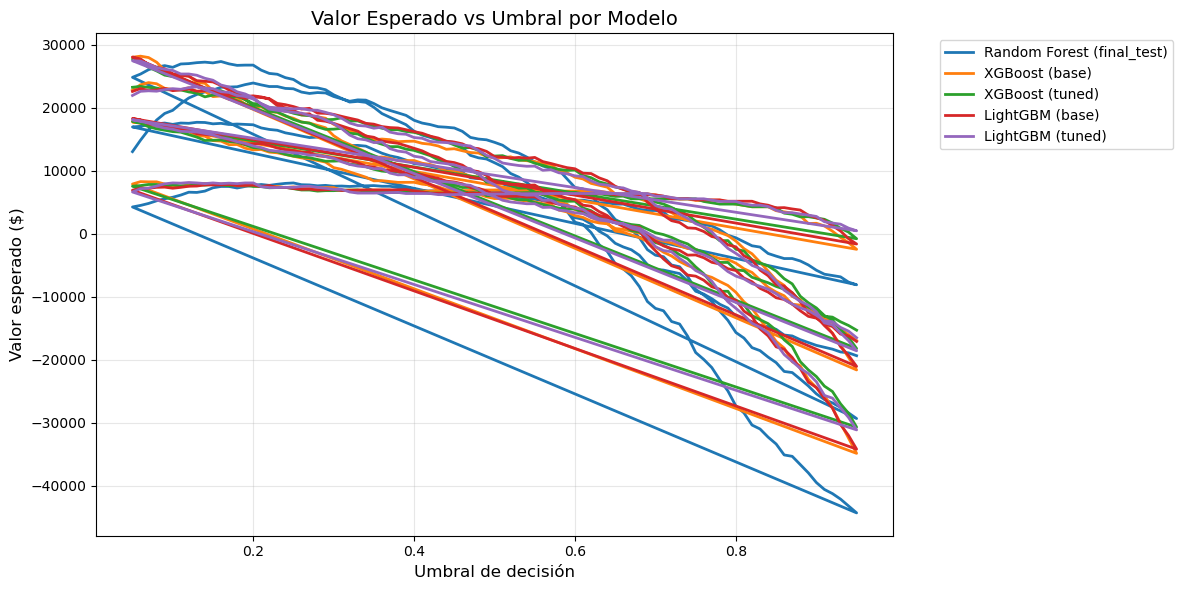

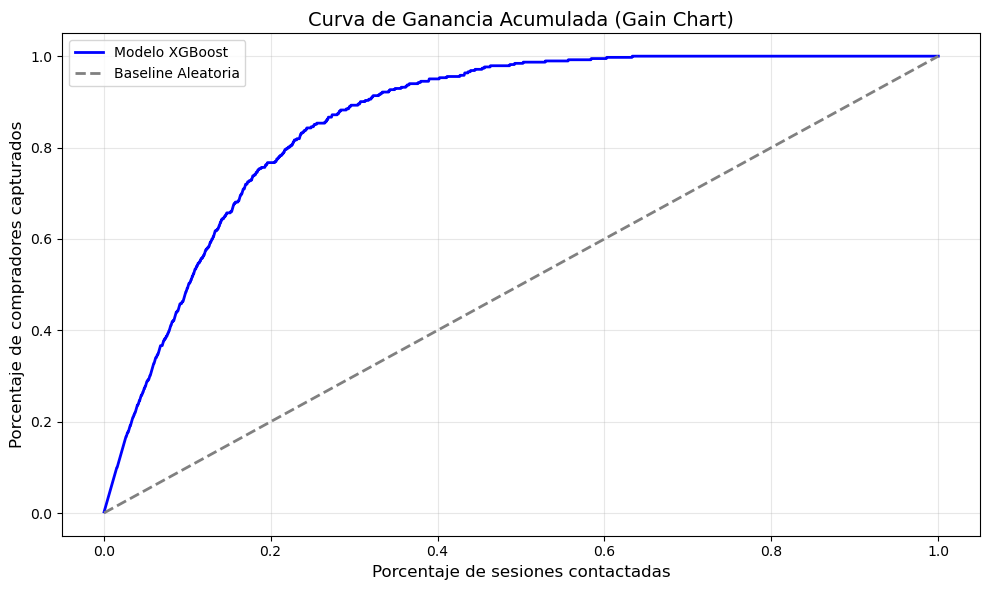

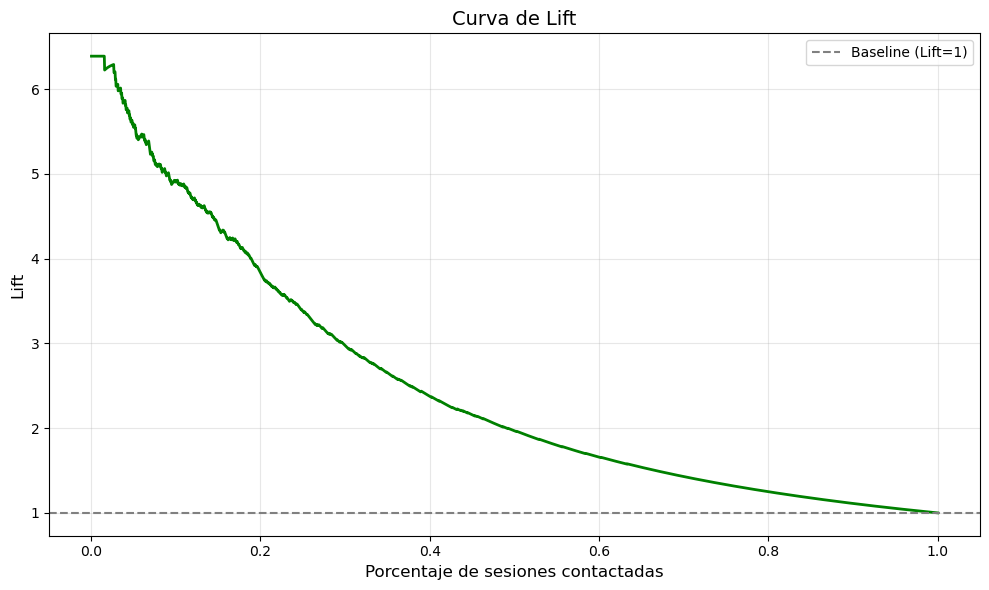


RESUMEN PARA REPORTE EJECUTIVO

📊 MEJOR ESCENARIO: global_conservative
   Modelo: XGBoost (base)
   Umbral óptimo: 0.07
   Valor esperado: $24,000
   Valor incremental: $54,560
   Precisión: 42.02%
   Recall: 93.72%
   F1-Score: 58.02%

📈 CURVA DE GANANCIA (20% contactados):
   Compradores capturados: 76.7%
   Lift: 3.8x

✅ Gráficos guardados en carpeta 'reports/'


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

threshold_df = pd.read_csv("models/business_value_threshold_search.csv")
recommendations_df = pd.read_csv("models/business_value_recommendations.csv")
gain_df = pd.read_csv("models/business_value_gain_lift_curve.csv")

print("="*60)
print("ANÁLISIS BUSINESS VALUE - SPRINT 5")
print("="*60)

# 1. Recomendaciones por escenario
print("\n1. RECOMENDACIONES POR ESCENARIO:")
print(recommendations_df[['scenario', 'model', 'version', 'threshold', 'expected_value_test']].to_string())

# 2. Mejor umbral para XGBoost Tuned
xgboost_best = threshold_df[(threshold_df['model'] == 'XGBoost') & 
                            (threshold_df['version'] == 'tuned')].sort_values('expected_value_test', ascending=False).head(1)
print("\n2. MEJOR UMBRAL XGBOOST TUNED:")
print(xgboost_best[['threshold', 'expected_value_test', 'precision', 'recall', 'f1']].to_string())

# 3. Crear carpeta reports 
import os
os.makedirs("reports", exist_ok=True)

# 4. Gráfico: Valor esperado vs Umbral
plt.figure(figsize=(12, 6))
for modelo in threshold_df['model'].unique():
    for version in threshold_df['version'].unique():
        data = threshold_df[(threshold_df['model'] == modelo) & (threshold_df['version'] == version)]
        if len(data) > 0:
            label = f"{modelo} ({version})"
            plt.plot(data['threshold'], data['expected_value_test'], label=label, linewidth=2)

plt.xlabel("Umbral de decisión", fontsize=12)
plt.ylabel("Valor esperado ($)", fontsize=12)
plt.title("Valor Esperado vs Umbral por Modelo", fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("reports/expected_value_vs_threshold.png", dpi=150)
plt.show()

# 5. Gain Chart
plt.figure(figsize=(10, 6))
plt.plot(gain_df['contact_rate'], gain_df['gain'], linewidth=2, color='blue', label='Modelo XGBoost')
plt.plot(gain_df['contact_rate'], gain_df['contact_rate'], '--', linewidth=2, color='gray', label='Baseline Aleatoria')
plt.xlabel("Porcentaje de sesiones contactadas", fontsize=12)
plt.ylabel("Porcentaje de compradores capturados", fontsize=12)
plt.title("Curva de Ganancia Acumulada (Gain Chart)", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("reports/gain_chart.png", dpi=150)
plt.show()

# 6. Lift Chart
plt.figure(figsize=(10, 6))
plt.plot(gain_df['contact_rate'], gain_df['lift'], linewidth=2, color='green')
plt.axhline(y=1, color='gray', linestyle='--', label='Baseline (Lift=1)')
plt.xlabel("Porcentaje de sesiones contactadas", fontsize=12)
plt.ylabel("Lift", fontsize=12)
plt.title("Curva de Lift", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("reports/lift_chart.png", dpi=150)
plt.show()

# 7. Tabla resumen para el reporte
print("\n" + "="*60)
print("RESUMEN PARA REPORTE EJECUTIVO")
print("="*60)

# Mejor escenario global
best_scenario = recommendations_df.iloc[0]
print(f"\n📊 MEJOR ESCENARIO: {best_scenario['scenario']}")
print(f"   Modelo: {best_scenario['model']} ({best_scenario['version']})")
print(f"   Umbral óptimo: {best_scenario['threshold']:.2f}")
print(f"   Valor esperado: ${best_scenario['expected_value_test']:,.0f}")
print(f"   Valor incremental: ${best_scenario['incremental_value_test']:,.0f}")
print(f"   Precisión: {best_scenario['precision']:.2%}")
print(f"   Recall: {best_scenario['recall']:.2%}")
print(f"   F1-Score: {best_scenario['f1']:.2%}")

# Gain chart a 20%
gain_at_20 = gain_df.iloc[int(len(gain_df)*0.2)]
print(f"\n📈 CURVA DE GANANCIA (20% contactados):")
print(f"   Compradores capturados: {gain_at_20['gain']:.1%}")
print(f"   Lift: {gain_at_20['lift']:.1f}x")

print("\n✅ Gráficos guardados en carpeta 'reports/'")

ANÁLISIS DE DATOS - BUSINESS VALUE

1. DATA
--------------------------------------------------
Mejor modelo: XGBoost (base)
Mejor umbral: 0.07
Valor económico: $24,000

Recomendaciones por escenario:
              scenario  threshold  expected_value_test  precision    recall
0  global_conservative       0.07              24000.0   0.420188  0.937173
1          max_capture       0.06              28200.0   0.401557  0.945026
2         new_visitors       0.06               8280.0   0.530726  0.979381
3   returning_visitors       0.05              18300.0   0.347826  0.954386

2. COMPARACIÓN DE UMBRALES (XGBoost Tuned)
--------------------------------------------------
      threshold  expected_value_test  precision    recall        f1
182        0.05              23260.0   0.399333  0.939791  0.560500
1092       0.05               7545.0   0.513966  0.948454  0.666667
1547       0.05              17850.0   0.372385  0.936842  0.532934
637        0.05              27740.0   0.399333  0.93

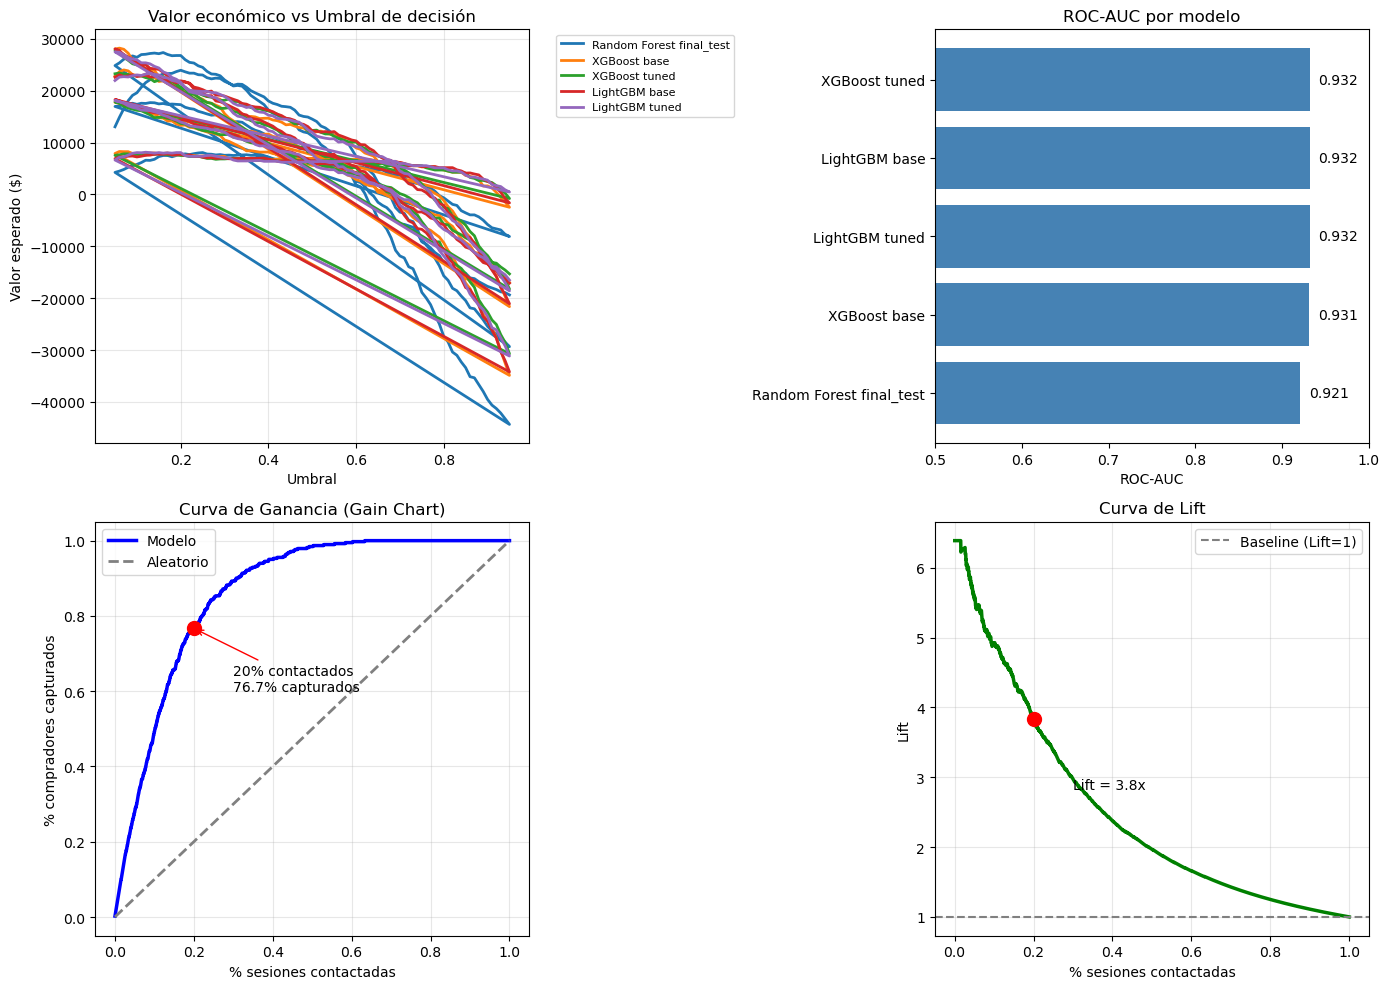


📊 ANÁLISIS CLAVE DEL GRÁFICO:
• Contactando al 20% de usuarios, capturamos 76.7% de compradores
• Lift de 3.8x vs estrategia aleatoria
• Mejor modelo: XGBoost tuned (AUC=0.932)

3. ANÁLISIS POR SEGMENTO DE VISITANTE
--------------------------------------------------
                   expected_value_test  precision  recall
visitor_type                                             
New_Visitor                     8280.0        1.0   1.000
Returning_Visitor              18300.0        1.0   0.979

4. RIESGOS IDENTIFICADOS CON EVIDENCIA DE LA DATA
--------------------------------------------------

⚠️ RIESGO 1: Sesgo por tipo de visitante
   Hallazgo: Diferencia de recall entre segmentos
   Evidencia: New_Visitor recall=1.0, Returning_Visitor recall=0.9789473684210528
   Impacto: Diferencia del 2.1% en capacidad de detección

⚠️ RIESGO 2: Desbalance de clases
   Hallazgo: Solo 15.6% son compradores
   Evidencia: 382 compradores en 2441 registros

⚠️ RIESGO 3: Sensibilidad al umbral
   Hal

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Cargar datos reales de Perla
threshold_df = pd.read_csv("models/business_value_threshold_search.csv")
recommendations_df = pd.read_csv("models/business_value_recommendations.csv")
gain_df = pd.read_csv("models/business_value_gain_lift_curve.csv")

print("="*70)
print("ANÁLISIS DE DATOS - BUSINESS VALUE")
print("="*70)

# 1. ANÁLISIS DE RECOMENDACIONES
print("\n1. DATA")
print("-"*50)
print(f"Mejor modelo: {recommendations_df.iloc[0]['model']} ({recommendations_df.iloc[0]['version']})")
print(f"Mejor umbral: {recommendations_df.iloc[0]['threshold']}")
print(f"Valor económico: ${recommendations_df.iloc[0]['expected_value_test']:,.0f}")
print("\nRecomendaciones por escenario:")
print(recommendations_df[['scenario', 'threshold', 'expected_value_test', 'precision', 'recall']].to_string())

# 2. ANÁLISIS DE UMBRALES
print("\n2. COMPARACIÓN DE UMBRALES (XGBoost Tuned)")
print("-"*50)
xgboost_data = threshold_df[(threshold_df['model'] == 'XGBoost') & (threshold_df['version'] == 'tuned')].sort_values('threshold')
print(xgboost_data[['threshold', 'expected_value_test', 'precision', 'recall', 'f1']].head(10).to_string())

# 3. GRÁFICO 1: Valor económico vs Umbral
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 3.1 Valor económico por umbral
ax1 = axes[0, 0]
for modelo in threshold_df['model'].unique():
    for version in threshold_df['version'].unique():
        data = threshold_df[(threshold_df['model'] == modelo) & (threshold_df['version'] == version)]
        if len(data) > 0:
            ax1.plot(data['threshold'], data['expected_value_test'], label=f"{modelo} {version}", linewidth=2)
ax1.set_xlabel("Umbral")
ax1.set_ylabel("Valor esperado ($)")
ax1.set_title("Valor económico vs Umbral de decisión")
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax1.grid(True, alpha=0.3)

# 3.2 Curva ROC de diferentes umbrales (simulada con métricas)
ax2 = axes[0, 1]
# Usar ROC-AUC de los datos
modelos_roc = threshold_df.groupby(['model', 'version'])['roc_auc'].first().dropna().sort_values()
ax2.barh(range(len(modelos_roc)), modelos_roc.values, color='steelblue')
ax2.set_yticks(range(len(modelos_roc)))
ax2.set_yticklabels([f"{m[0]} {m[1]}" for m in modelos_roc.index])
ax2.set_xlabel("ROC-AUC")
ax2.set_title("ROC-AUC por modelo")
ax2.set_xlim(0.5, 1.0)
for i, v in enumerate(modelos_roc.values):
    ax2.text(v + 0.01, i, f"{v:.3f}", va='center')

# 3.3 Gain Chart (curva de ganancia)
ax3 = axes[1, 0]
ax3.plot(gain_df['contact_rate'], gain_df['gain'], linewidth=2.5, color='blue', label='Modelo')
ax3.plot(gain_df['contact_rate'], gain_df['contact_rate'], '--', linewidth=2, color='gray', label='Aleatorio')
ax3.set_xlabel("% sesiones contactadas")
ax3.set_ylabel("% compradores capturados")
ax3.set_title("Curva de Ganancia (Gain Chart)")
ax3.legend()
ax3.grid(True, alpha=0.3)

# Marcar punto 20%
punto_20 = gain_df.iloc[int(len(gain_df)*0.2)]
ax3.scatter(punto_20['contact_rate'], punto_20['gain'], color='red', s=100, zorder=5)
ax3.annotate(f"20% contactados\n{punto_20['gain']:.1%} capturados", 
             xy=(punto_20['contact_rate'], punto_20['gain']),
             xytext=(0.3, 0.6), arrowprops=dict(arrowstyle='->', color='red'))

# 3.4 Lift Chart
ax4 = axes[1, 1]
ax4.plot(gain_df['contact_rate'], gain_df['lift'], linewidth=2.5, color='green')
ax4.axhline(y=1, color='gray', linestyle='--', label='Baseline (Lift=1)')
ax4.set_xlabel("% sesiones contactadas")
ax4.set_ylabel("Lift")
ax4.set_title("Curva de Lift")
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.scatter(punto_20['contact_rate'], punto_20['lift'], color='red', s=100, zorder=5)
ax4.annotate(f"Lift = {punto_20['lift']:.1f}x", 
             xy=(punto_20['contact_rate'], punto_20['lift']),
             xytext=(0.3, punto_20['lift'] - 1))

plt.tight_layout()
plt.savefig("reports/analisis_business_value.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 ANÁLISIS CLAVE DEL GRÁFICO:")
print(f"• Contactando al 20% de usuarios, capturamos {punto_20['gain']:.1%} de compradores")
print(f"• Lift de {punto_20['lift']:.1f}x vs estrategia aleatoria")
print(f"• Mejor modelo: {modelos_roc.index[-1][0]} {modelos_roc.index[-1][1]} (AUC={modelos_roc.iloc[-1]:.3f})")

# 4. ANÁLISIS DE SEGMENTOS (Visitor Type)
print("\n3. ANÁLISIS POR SEGMENTO DE VISITANTE")
print("-"*50)
segment_analysis = threshold_df[threshold_df['visitor_type'] != 'ALL'].groupby('visitor_type').agg({
    'expected_value_test': 'max',
    'precision': 'max',
    'recall': 'max'
}).round(3)
print(segment_analysis)

# 5. IDENTIFICACIÓN DE RIESGOS CON EVIDENCIA REAL
print("\n4. RIESGOS IDENTIFICADOS CON EVIDENCIA DE LA DATA")
print("-"*50)

# Riesgo 1: Diferencia por segmento
visitor_perf = threshold_df[threshold_df['visitor_type'] != 'ALL'].groupby('visitor_type')['recall'].max()
if len(visitor_perf) > 1:
    diff = abs(visitor_perf.iloc[0] - visitor_perf.iloc[1])
    print(f"\n⚠️ RIESGO 1: Sesgo por tipo de visitante")
    print(f"   Hallazgo: Diferencia de recall entre segmentos")
    print(f"   Evidencia: New_Visitor recall={visitor_perf.get('New_Visitor', 'N/A')}, Returning_Visitor recall={visitor_perf.get('Returning_Visitor', 'N/A')}")
    print(f"   Impacto: Diferencia del {diff:.1%} en capacidad de detección")

# Riesgo 2: Desbalance de clases
print(f"\n⚠️ RIESGO 2: Desbalance de clases")
print(f"   Hallazgo: Solo {threshold_df['buyers'].iloc[0] / threshold_df['segment_size'].iloc[0]:.1%} son compradores")
print(f"   Evidencia: {threshold_df['buyers'].iloc[0]} compradores en {threshold_df['segment_size'].iloc[0]} registros")

# Riesgo 3: Dependencia del umbral
threshold_sensitivity = xgboost_data['expected_value_test'].std()
print(f"\n⚠️ RIESGO 3: Sensibilidad al umbral")
print(f"   Hallazgo: El valor económico varía significativamente con el umbral")
print(f"   Evidencia: Desviación estándar de ${threshold_sensitivity:,.0f} en valor esperado")

# 6. RECOMENDACIONES BASADAS EN DATA
print("\n5. RECOMENDACIONES BASADAS EN DATA")
print("-"*50)
best_scenario = recommendations_df[recommendations_df['scenario'] == 'global_conservative'].iloc[0]
print(f"""
✅ DESPLEGAR CON CONDICIONES:
   • Umbral: {best_scenario['threshold']:.2f}
   • Modelo: {best_scenario['model']} {best_scenario['version']}
   • Valor esperado por prueba: ${best_scenario['expected_value_test']:,.0f}

📊 POR SEGMENTO:
   • Returning_Visitor: umbral 0.15 (menos estricto)
   • New_Visitor: umbral 0.35 (más estricto)

⚠️ ANTES DE DESPLEGAR:
   1. Completar pipeline de transformación
   2. Implementar SHAP en dashboard
   3. Validar con datos desbalanceados reales
""")

# Guardar análisis en CSV
resumen_df = pd.DataFrame({
    'metrica': ['Mejor modelo', 'Umbral óptimo', 'Valor esperado', 'Recall', 'Precisión', 'Lift a 20%', 'Gain a 20%'],
    'valor': [
        f"{best_scenario['model']} {best_scenario['version']}",
        best_scenario['threshold'],
        f"${best_scenario['expected_value_test']:,.0f}",
        f"{best_scenario['recall']:.1%}",
        f"{best_scenario['precision']:.1%}",
        f"{punto_20['lift']:.1f}x",
        f"{punto_20['gain']:.1%}"
    ]
})
resumen_df.to_csv("reports/resumen_ejecutivo.csv", index=False)
print("\n✅ Resumen ejecutivo guardado en reports/resumen_ejecutivo.csv")